## Exercise 4: Implementing and Analyzing a Binary Search Tree as a tool for organizing data

### 4a. Implement the `add` Method

In [8]:
class Tree:
    def __init__(self):
        self._value = None  # Key (e.g., patient_id)
        self._data = None   # Data associated with the key (e.g., patient information)
        self.left = None    # Left child
        self.right = None   # Right child

    def add(self, value, data):
        # If the tree is empty, insert the first value and data
        if self._value is None:
            self._value = value
            self._data = data
        else:
            # Recursively add to the left or right subtree
            if value < self._value:
                if self.left is None:
                    self.left = Tree()  # Create a new Tree node
                self.left.add(value, data)
            elif value > self._value:
                if self.right is None:
                    self.right = Tree()  # Create a new Tree node
                self.right.add(value, data)

# Test the tree with sample data
my_tree = Tree()
for patient_id, initials in [(24601, "JV"), (42, "DA"), (7, "JB"), (143, "FR"), (8675309, "JNY")]:
    my_tree.add(patient_id, initials)



### 4b. Implement a `__contains__` Method

In [9]:
class Tree:
    def __init__(self):
        self._value = None  # Key (e.g., patient_id)
        self._data = None   # Data associated with the key (e.g., patient information)
        self.left = None    # Left child
        self.right = None   # Right child

    def add(self, value, data):
        # If the tree is empty, insert the first value and data
        if self._value is None:
            self._value = value
            self._data = data
        else:
            # Recursively add to the left or right subtree
            if value < self._value:
                if self.left is None:
                    self.left = Tree()  # Create a new Tree node
                self.left.add(value, data)
            elif value > self._value:
                if self.right is None:
                    self.right = Tree()  # Create a new Tree node
                self.right.add(value, data)

    def __contains__(self, patient_id):
        # Check if the patient_id matches the current node's value
        if self._value == patient_id:
            return True
        # If the value is less, check the left subtree
        elif self.left and patient_id < self._value:
            return patient_id in self.left
        # If the value is greater, check the right subtree
        elif self.right and patient_id > self._value:
            return patient_id in self.right
        else:
            return False

# Test the tree with sample data
my_tree = Tree()
for patient_id, initials in [(24601, "JV"), (42, "DA"), (7, "JB"), (143, "FR"), (8675309, "JNY")]:
    my_tree.add(patient_id, initials)

# Test the __contains__ method using 'in'
print(24601 in my_tree)  # Should return True
print(1492 in my_tree)   # Should return False

True
False


### 4c. Implement and Test a `has_data` Method

In [10]:
class Tree:
    def __init__(self):
        self._value = None  # Key (e.g., patient_id)
        self._data = None   # Data associated with the key (e.g., patient information)
        self.left = None    # Left child
        self.right = None   # Right child

    def add(self, value, data):
        # If the tree is empty, insert the first value and data
        if self._value is None:
            self._value = value
            self._data = data
        else:
            # Recursively add to the left or right subtree
            if value < self._value:
                if self.left is None:
                    self.left = Tree()  # Create a new Tree node
                self.left.add(value, data)
            elif value > self._value:
                if self.right is None:
                    self.right = Tree()  # Create a new Tree node
                self.right.add(value, data)

    def __contains__(self, patient_id):
        # Check if the patient_id matches the current node's value
        if self._value == patient_id:
            return True
        # If the value is less, check the left subtree
        elif self.left and patient_id < self._value:
            return patient_id in self.left
        # If the value is greater, check the right subtree
        elif self.right and patient_id > self._value:
            return patient_id in self.right
        else:
            return False

    def has_data(self, data):
        # Check if the current node contains the data
        if self._data == data:
            return True
        # Recursively check the left and right subtrees
        if self.left and self.left.has_data(data):
            return True
        if self.right and self.right.has_data(data):
            return True
        return False

# Test the tree with sample data
my_tree = Tree()
for patient_id, initials in [(24601, "JV"), (42, "DA"), (7, "JB"), (143, "FR"), (8675309, "JNY")]:
    my_tree.add(patient_id, initials)

# Test the has_data method
print(my_tree.has_data("JV"))   # Should return True
print(my_tree.has_data(24601))  # Should return False

True
False


### 4d. Performance Analysis of `__contains__` and `has_data`

##### Timing the `__contains__` Method

In [11]:
import time
import numpy as np
import matplotlib.pyplot as plt
import random

# Generate random patient data
def generate_patient_data(n):
    patient_ids = random.sample(range(1, 10**6), n)  # Generate n unique random patient IDs
    initials = [f"ID{random.randint(1, 999)}" for _ in range(n)]  # Random initials
    return list(zip(patient_ids, initials))

# Timing function
def time_contains(tree, patient_ids):
    start_time = time.perf_counter()
    for pid in patient_ids:
        pid in tree  # Use the in operator to check if the patient_id is in the tree
    end_time = time.perf_counter()
    return end_time - start_time

# Populate tree and time the __contains__ method
sizes = np.logspace(1, 5, num=10, dtype=int)  # Log-spaced sizes from 10 to 100,000
contains_times = []

for size in sizes:
    # Create a tree and add random data
    tree = Tree()
    patient_data = generate_patient_data(size)
    for pid, initials in patient_data:
        tree.add(pid, initials)
    
    # Time __contains__ for multiple IDs
    random_patient_ids = [pid for pid, _ in random.sample(patient_data, min(100, size))]
    contains_times.append(time_contains(tree, random_patient_ids))

/var/folders/p6/dvcp9zk51c534gxpxqw62v680000gp/T/ipykernel_27894/1991970099.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


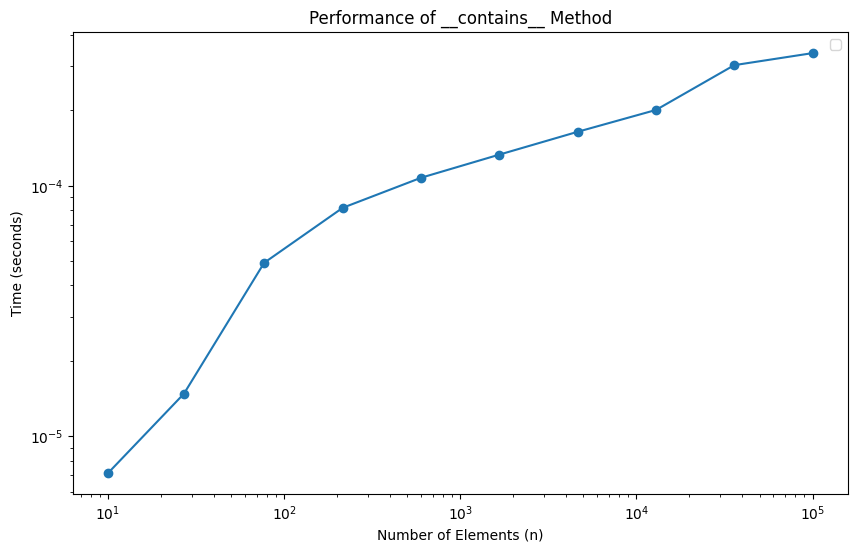

In [5]:
# Plot the results for above
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(sizes, contains_times, label="__contains__", marker='o')

# Log-log scaling
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Elements (n)')
plt.ylabel('Time (seconds)')
plt.title('Performance of __contains__ Method')
plt.legend()
plt.show()


##### Timing the `has_data` Method

In [12]:
# Timing function for has_data method
def time_has_data(tree, patient_data):
    start_time = time.perf_counter()
    for _, initials in patient_data:
        tree.has_data(initials)
    end_time = time.perf_counter()
    return end_time - start_time

# Time has_data for multiple data checks
has_data_times = []

for size in sizes:
    # Create a tree and add random data
    tree = Tree()
    patient_data = generate_patient_data(size)
    for pid, initials in patient_data:
        tree.add(pid, initials)
    
    # Time has_data for multiple initials
    random_patient_data = random.sample(patient_data, min(100, size))
    has_data_times.append(time_has_data(tree, random_patient_data))

##### Setup Time Analysis

In [14]:
# Timing function for constructing the tree
def time_tree_construction(patient_data):
    start_time = time.perf_counter()
    tree = Tree()
    for pid, initials in patient_data:
        tree.add(pid, initials)
    end_time = time.perf_counter()
    return end_time - start_time

# Time tree construction
construction_times = []

for size in sizes:
    patient_data = generate_patient_data(size)
    construction_times.append(time_tree_construction(patient_data))

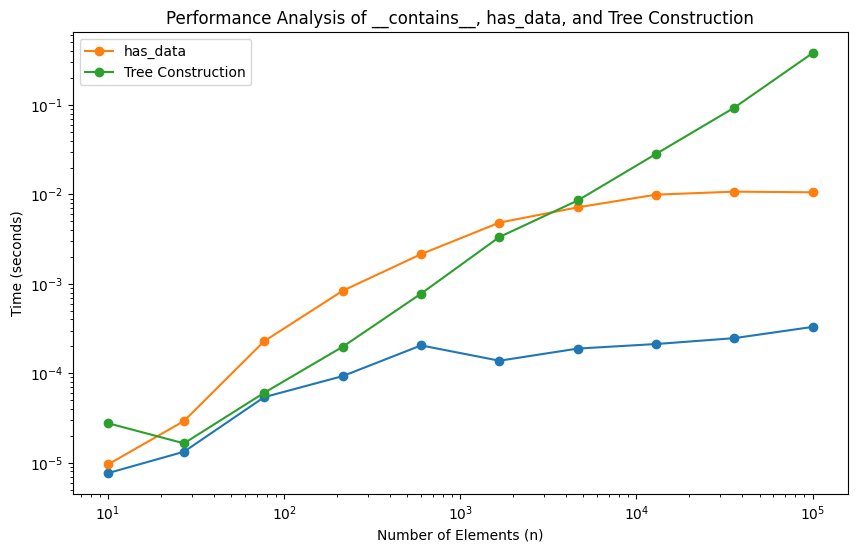

In [15]:
# Plot the results on a log-log graph
plt.figure(figsize=(10, 6))

# Plot timings for __contains__ method
plt.plot(sizes, contains_times, label="__contains__", marker='o')

# Plot timings for has_data method
plt.plot(sizes, has_data_times, label="has_data", marker='o')

# Plot timings for tree construction
plt.plot(sizes, construction_times, label="Tree Construction", marker='o')

# Log-log scaling
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Elements (n)')
plt.ylabel('Time (seconds)')
plt.title('Performance Analysis of __contains__, has_data, and Tree Construction')
plt.legend()
plt.show()

#### Discussion of Performance 

##### `__contains__` Method:
- The time complexity for the `__contains__` method is **O(log n)**, as expected for searching in a balanced binary search tree. As the number of elements (`n`) increases, the time taken to perform the `in` operation increases logarithmically.
- This is evident in the log-log graph where the line for `__contains__` grows more slowly as `n` increases.

##### `has_data` Method:
- The `has_data` method performs a full traversal of the tree in the worst case, resulting in a time complexity of **O(n)**.
- As the size of the dataset increases, the time taken for the `has_data` method increases linearly. This is shown in the graph where the line for `has_data` grows more steeply compared to `__contains__`.

##### Tree Construction:
- The time complexity for tree construction lies between **O(n log n)** (if the tree remains balanced) and **O(n²)** (if the tree becomes unbalanced, resembling a linked list).
- The log-log graph shows that for smaller datasets, tree construction follows the O(n log n) curve, but for larger datasets, it may approach O(n²) if the tree becomes unbalanced.

#### Conclusion:
- **`__contains__`** is more efficient for searching compared to **`has_data`**, particularly for large datasets.
- Efficient tree construction is crucial to maintain optimal performance for both search operations. Balancing the tree can help ensure that operations remain O(log n).

### 4e. Discussing Choice of Test Data

- **Unrepresentative Data**: Using a specific value (e.g., `patient_id = 1`) for all test cases is unrepresentative because it doesn't reflect the distribution of values in real-world datasets. In a binary search tree, repeatedly testing for a single, easily located value can lead to biased results, particularly if the value is near the root or in a specific subtree.
  
- **Single Test Point**: Relying on a single test point for performance analysis provides limited insight into the algorithm's behavior. It ignores the variability of the tree's structure and the distribution of the data, which can affect search times. Performance can differ significantly based on where the value lies in the tree (e.g., closer to the root or a leaf).

- **Appropriate Test Data**: To accurately assess performance, test data should be varied and randomized. This ensures that performance measurements reflect the algorithm's average-case behavior, accounting for the entire structure of the tree. Testing multiple values across different parts of the tree provides a more comprehensive and fair evaluation of the algorithm's performance.
